# EDA - Life_Style_Data.csv

## Chargement et inspection initiale

### Objectif
Vérifier que le fichier `Life_Style_Data.csv` est correctement chargé et obtenir une vue d’ensemble :
- dimensions du jeu de données (nombre de lignes et de colonnes),
- typage des variables (numériques, catégorielles, booléennes),
- détection des valeurs manquantes et doublons,
- cohérence générale du corpus avant analyse statistique.

### Interprétation attendue
- Le dataset devrait comporter une cinquantaine de colonnes, combinant données **physiques, comportementales et nutritionnelles**.  
- Les types doivent être correctement inférés : numériques (`Age`, `Weight`, `Calories_Burned`), catégorielles (`Gender`, `Workout_Type`), booléennes (`is_healthy`).  
- On identifiera les **colonnes à forte proportion de valeurs manquantes** afin de décider ultérieurement d’un traitement (imputation, suppression, ou encodage spécial).  
- La détection de **doublons** permettra d’évaluer la fiabilité du corpus et la diversité des observations.  
- Enfin, l’inspection des noms de colonnes garantira la cohérence du dictionnaire des données avant les analyses statistiques.

### Importation des librairies essentielles

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# === Localiser automatiquement le package 'themes' en remontant l'arborescence ===
from pathlib import Path
import sys

root = Path.cwd()           # ex: .../DuckDB/eda/life_style_data
themes_root = None

for p in [root, *root.parents]:   # remonte: life_style_data -> eda -> DuckDB -> ...
    if (p / "themes").is_dir():
        themes_root = p
        break

if themes_root is None:
    raise FileNotFoundError(
        f"Impossible de trouver le dossier 'themes' en partant de {root}. "
        "Vérifie l'arborescence (il doit exister un dossier 'themes/' quelque part au-dessus)."
    )

if str(themes_root) not in sys.path:
    sys.path.insert(0, str(themes_root))

print("✅ Ajouté au PYTHONPATH :", themes_root)
print("📁 Contenu de", themes_root, ":", [x.name for x in (themes_root).iterdir()])


# Thème personnalisé du projet (uniquement pour les notebooks)
from themes.theme_train_me import set_trainme_theme

c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\.conda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Ajouté au PYTHONPATH : c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\notebooks
📁 Contenu de c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\notebooks : ['eda', 'themes', '__init__.py']


### Configuration d'affichage pour plus de lisibilité

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

### Thème “TrAIn.me”
Il applique un fond dark propre, une grille discrète, des ticks lisibles, et une palette bleus/cians cohérente.

In [3]:
# =============================
# Thème TrAIn.me (Seaborn/Matplotlib)
# =============================
# Booléen de contrôle : True = thème TrAIn.me (dark), False = style clair "ticks"
USE_DARK_THEME = True  # ⬅️ modifie ici selon le contexte

# Activer le thème au début du notebook :
palette_trainme = set_trainme_theme(context="talk", font_scale=1.05, use_dark=True)
palette_trainme

['#00E5FF', '#00BFFF', '#0A84FF', '#1E90FF', '#00FFFF', '#64D8FF']

### Chargement du dataset

In [4]:
# Construction du chemin relatif
# file_path = "../../datasets/Life_Style_Data.csv"

# Téléchargement du dataset depuis Kaggle
dataset_path = kagglehub.dataset_download("jockeroika/life-style-data")

# Recherche du fichier CSV dans le dossier téléchargé
csv_files = [f for f in os.listdir(dataset_path) if f.endswith(".csv")]
print("Fichiers trouvés :", csv_files)

# Construction du chemin complet vers le CSV
file_path = os.path.join(dataset_path, csv_files[0])


# Lecture du fichier CSV
df = pd.read_csv(file_path)

# Informations de confirmation
print("Dataset chargé avec succès !")
print(f"Dimensions : {df.shape[0]} lignes et {df.shape[1]} colonnes\n")


Fichiers trouvés : ['Final_data.csv', 'meal_metadata.csv']
Dataset chargé avec succès !
Dimensions : 20000 lignes et 54 colonnes



### Aperçu général des premières lignes

In [5]:
display(df.head())

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Daily meals frequency,Physical exercise,Carbs,Proteins,Fats,Calories,meal_name,meal_type,diet_type,sugar_g,sodium_mg,cholesterol_mg,serving_size_g,cooking_method,prep_time_min,cook_time_min,rating,Name of Exercise,Sets,Reps,Benefit,Burns Calories (per 30 min),Target Muscle Group,Equipment Needed,Difficulty Level,Body Part,Type of Muscle,Workout,BMI_calc,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns Calories (per 30 min)_bc,Burns_Calories_Bin
0,34.91,Male,65.27,1.62,188.58,157.65,69.05,1.00,1080.90,Strength,26.800377,1.50,3.99,2.01,24.87,2.99,0.01,267.68,106.05,71.63,1806.0,Other,Lunch,Vegan,31.77,1729.94,285.05,120.47,Grilled,16.24,110.79,1.31,Decline Push-ups,4.99,20.91,Improves shoulder health and posture,342.58,"Shoulders, Triceps",Cable Machine,Advanced,Legs,Lats,Dumbbell flyes,24.870447,2139.59,0.500432,1.624789,0.741237,0.835985,725.10,47.777394,685.1600,7.260425e+19,Medium
1,23.37,Female,56.41,1.55,179.43,131.75,73.18,1.37,1809.91,HIIT,27.655021,1.90,4.00,2.01,23.48,3.01,0.97,214.32,85.41,56.97,1577.0,Other,Lunch,Vegetarian,12.34,693.08,300.61,109.15,Fried,16.47,12.01,1.92,Bear Crawls,4.01,16.15,Strengthens lower abs,357.16,"Back, Core, Shoulders",Step or Box,Intermediate,Chest,Lats,Lateral raises,23.479709,1711.65,0.500850,1.514093,0.551247,0.734270,-232.91,40.809803,978.6184,1.020506e+20,High
2,33.20,Female,58.98,1.67,175.04,123.95,54.96,0.91,802.26,Cardio,24.320821,1.88,2.99,1.02,21.15,1.99,-0.02,246.04,98.11,65.48,1608.0,Other,Breakfast,Paleo,42.81,2142.48,215.42,399.43,Boiled,54.35,6.09,4.70,Dips,5.00,21.90,Builds chest strength,359.63,"Quadriceps, Glutes",Step or Box,Intermediate,Arms,Grip Strength,Standing calf raises,21.148123,1965.92,0.500610,1.663445,0.574534,0.708124,805.74,44.635580,654.5266,1.079607e+20,High
3,38.69,Female,93.78,1.70,191.21,155.10,50.07,1.10,1450.79,HIIT,32.813572,2.50,3.99,1.99,32.45,3.00,0.04,203.22,80.84,54.56,2657.0,Other,Lunch,Paleo,9.34,123.20,9.70,314.31,Fried,27.73,103.72,4.85,Mountain Climbers,4.01,16.92,Improves coordination and cardiovascular health,351.65,"Biceps, Forearms",Parallel Bars or Chair,Advanced,Shoulders,Upper,Incline dumbbell flyes,32.449827,1627.28,0.499533,0.862017,0.744155,0.811150,1206.21,63.007432,773.6300,8.987921e+19,High
4,45.09,Male,52.42,1.88,193.58,152.88,70.84,1.08,1166.40,Strength,17.307319,2.91,4.00,2.00,14.83,3.00,3.00,332.79,133.05,88.43,1470.0,Other,Breakfast,Vegan,23.78,1935.11,116.89,99.22,Baked,34.16,46.55,3.07,Bicep Curls,4.99,15.01,Targets obliques and improves core rotation,329.36,"Chest, Triceps",Wall,Advanced,Abs,Wrist Flexors,Military press,14.831372,2659.23,0.500581,2.538153,0.668405,0.789751,303.60,43.347504,711.4176,5.264685e+19,Low


### Informations générales sur le typage et la complétude

In [6]:
df_info = df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 54 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             20000 non-null  float64
 1   Gender                          20000 non-null  object 
 2   Weight (kg)                     20000 non-null  float64
 3   Height (m)                      20000 non-null  float64
 4   Max_BPM                         20000 non-null  float64
 5   Avg_BPM                         20000 non-null  float64
 6   Resting_BPM                     20000 non-null  float64
 7   Session_Duration (hours)        20000 non-null  float64
 8   Calories_Burned                 20000 non-null  float64
 9   Workout_Type                    20000 non-null  object 
 10  Fat_Percentage                  20000 non-null  float64
 11  Water_Intake (liters)           20000 non-null  float64
 12  Workout_Frequency (days/week)   

### Statistiques descriptives des variables numériques

In [7]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Age,20000.0,3.885145e+01,1.211458e+01,1.800000e+01,2.817000e+01,3.986500e+01,4.963000e+01,5.967000e+01
Weight (kg),20000.0,7.389883e+01,2.117301e+01,3.918000e+01,5.816000e+01,7.000000e+01,8.610000e+01,1.307700e+02
Height (m),20000.0,1.723094e+00,1.270328e-01,1.490000e+00,1.620000e+00,1.710000e+00,1.800000e+00,2.010000e+00
Max_BPM,20000.0,1.798897e+02,1.151081e+01,1.593100e+02,1.700575e+02,1.801400e+02,1.894250e+02,1.996400e+02
Avg_BPM,20000.0,1.437043e+02,1.426769e+01,1.190700e+02,1.312200e+02,1.429900e+02,1.560600e+02,1.698400e+02
Resting_BPM,20000.0,6.219581e+01,7.289351e+00,4.949000e+01,5.596000e+01,6.220000e+01,6.809000e+01,7.450000e+01
Session_Duration (hours),20000.0,1.259446e+00,3.413362e-01,4.900000e-01,1.050000e+00,1.270000e+00,1.460000e+00,2.020000e+00
Calories_Burned,20000.0,1.280110e+03,5.022290e+02,3.231100e+02,9.108000e+02,1.231450e+03,1.553112e+03,2.890820e+03
Fat_Percentage,20000.0,2.610131e+01,4.996160e+00,1.133313e+01,2.238781e+01,2.582250e+01,2.967603e+01,3.500000e+01
Water_Intake (liters),20000.0,2.627486e+00,6.047240e-01,1.460000e+00,2.170000e+00,2.610000e+00,3.120000e+00,3.730000e+00


### Analyse des valeurs manquantes et doublons

In [8]:
missing_values = df.isnull().sum().sort_values(ascending=False)
duplicates = df.duplicated().sum()

print("\n--- Valeurs manquantes par colonne (top 10) ---")
display(missing_values.head(10))

print(f"\nNombre total de doublons détectés : {duplicates}")


--- Valeurs manquantes par colonne (top 10) ---


Age                            0
Body Part                      0
prep_time_min                  0
cook_time_min                  0
rating                         0
Name of Exercise               0
Sets                           0
Reps                           0
Benefit                        0
Burns Calories (per 30 min)    0
dtype: int64


Nombre total de doublons détectés : 0


### Liste complète des colonnes disponibles

In [9]:
print("\n--- Liste des colonnes du dataset ---")
print(df.columns.tolist())


--- Liste des colonnes du dataset ---
['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI', 'Daily meals frequency', 'Physical exercise', 'Carbs', 'Proteins', 'Fats', 'Calories', 'meal_name', 'meal_type', 'diet_type', 'sugar_g', 'sodium_mg', 'cholesterol_mg', 'serving_size_g', 'cooking_method', 'prep_time_min', 'cook_time_min', 'rating', 'Name of Exercise', 'Sets', 'Reps', 'Benefit', 'Burns Calories (per 30 min)', 'Target Muscle Group', 'Equipment Needed', 'Difficulty Level', 'Body Part', 'Type of Muscle', 'Workout', 'BMI_calc', 'cal_from_macros', 'pct_carbs', 'protein_per_kg', 'pct_HRR', 'pct_maxHR', 'cal_balance', 'lean_mass_kg', 'expected_burn', 'Burns Calories (per 30 min)_bc', 'Burns_Calories_Bin']


## Statistiques descriptives et distribution des variables

### Objectif
Explorer la distribution des variables numériques afin de comprendre la variabilité du dataset,
identifier d’éventuelles anomalies et détecter les premiers signaux statistiques utiles.


### Interprétation attendue
- Confirmer la cohérence statistique des variables physiologiques (âge, poids, taille, IMC).  
- Vérifier la normalité ou l’asymétrie de certaines distributions (Calories_Burned, BMI…).  
- Identifier visuellement les outliers potentiels pour un traitement futur.  


### Activation du thème TrAIn.me

In [10]:
if USE_DARK_THEME:
    palette_trainme = set_trainme_theme(context="talk", font_scale=1.05, use_dark=True)
else:
    sns.set_style("ticks")              # style clair sobre, axes renforcés
    sns.set_context("talk", font_scale=1.05)
    palette_trainme = sns.color_palette("deep")  # palette par défaut sobre
    print("🎨 Style activé : 'ticks' → sobre, axes renforcés (présentation pro)")

# Exemple de vérification :
print("Palette active :", palette_trainme.as_hex() if hasattr(palette_trainme, "as_hex") else palette_trainme)


Palette active : ['#00E5FF', '#00BFFF', '#0A84FF', '#1E90FF', '#00FFFF', '#64D8FF']


### Statistiques descriptives globales

In [11]:
stats = df.describe().T
display(stats)
# Vérification des bornes extrêmes sur les principales métriques
print(f"Âge moyen : {df['Age'].mean():.1f} ans")
print(f"Poids moyen : {df['Weight (kg)'].mean():.1f} kg")
print(f"Calories moyennes brûlées : {df['Calories_Burned'].mean():.0f} kcal")
print(f"IMC moyen : {df['BMI'].mean():.1f}")

,count,mean,std,min,25%,50%,75%,max
Age,20000.0,3.885145e+01,1.211458e+01,1.800000e+01,2.817000e+01,3.986500e+01,4.963000e+01,5.967000e+01
Weight (kg),20000.0,7.389883e+01,2.117301e+01,3.918000e+01,5.816000e+01,7.000000e+01,8.610000e+01,1.307700e+02
Height (m),20000.0,1.723094e+00,1.270328e-01,1.490000e+00,1.620000e+00,1.710000e+00,1.800000e+00,2.010000e+00
Max_BPM,20000.0,1.798897e+02,1.151081e+01,1.593100e+02,1.700575e+02,1.801400e+02,1.894250e+02,1.996400e+02
Avg_BPM,20000.0,1.437043e+02,1.426769e+01,1.190700e+02,1.312200e+02,1.429900e+02,1.560600e+02,1.698400e+02
Resting_BPM,20000.0,6.219581e+01,7.289351e+00,4.949000e+01,5.596000e+01,6.220000e+01,6.809000e+01,7.450000e+01
Session_Duration (hours),20000.0,1.259446e+00,3.413362e-01,4.900000e-01,1.050000e+00,1.270000e+00,1.460000e+00,2.020000e+00
Calories_Burned,20000.0,1.280110e+03,5.022290e+02,3.231100e+02,9.108000e+02,1.231450e+03,1.553112e+03,2.890820e+03
Fat_Percentage,20000.0,2.610131e+01,4.996160e+00,1.133313e+01,2.238781e+01,2.582250e+01,2.967603e+01,3.500000e+01
Water_Intake (liters),20000.0,2.627486e+00,6.047240e-01,1.460000e+00,2.170000e+00,2.610000e+00,3.120000e+00,3.730000e+00


Âge moyen : 38.9 ans
Poids moyen : 73.9 kg
Calories moyennes brûlées : 1280 kcal
IMC moyen : 24.9


### Distribution des variables clés

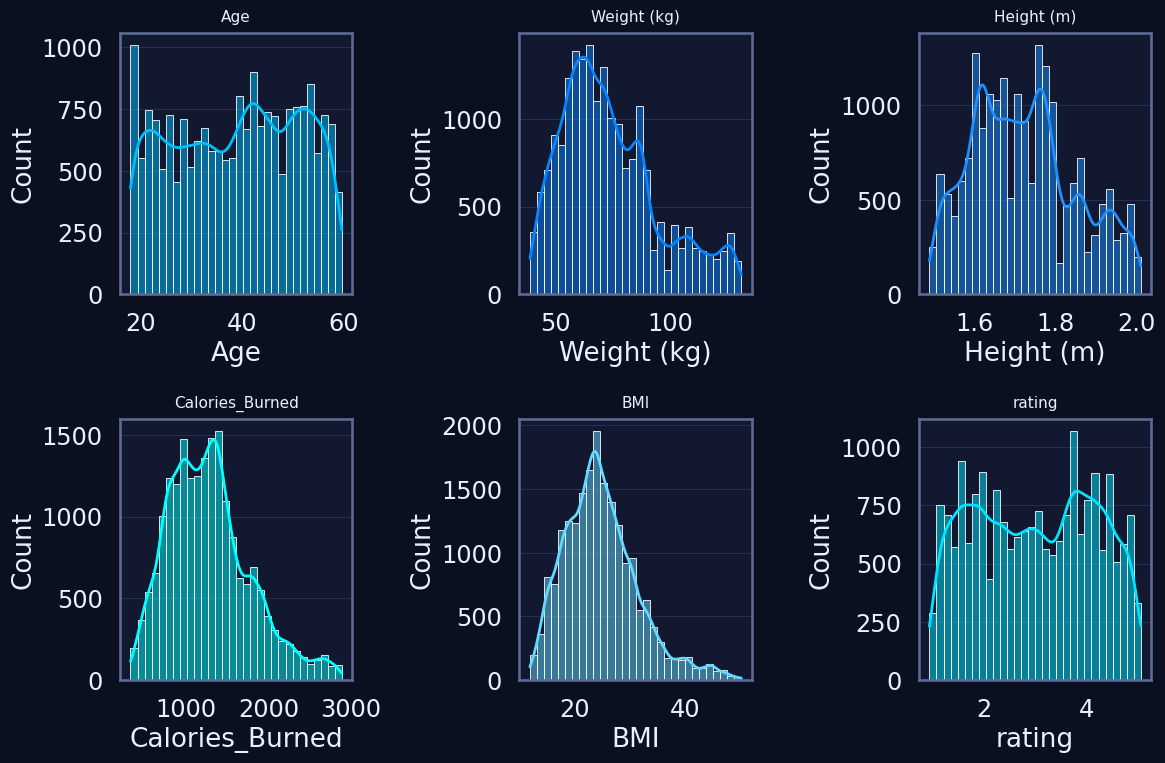

In [12]:
num_vars = ["Age", "Weight (kg)", "Height (m)", "Calories_Burned", "BMI", "rating"]

plt.figure(figsize=(12, 8))
for i, col in enumerate(num_vars, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], bins=30, kde=True, color=palette_trainme[i % len(palette_trainme)])
    plt.title(col, fontsize=11, pad=8)
plt.tight_layout()
plt.show()

### Boxplots pour repérer les outliers

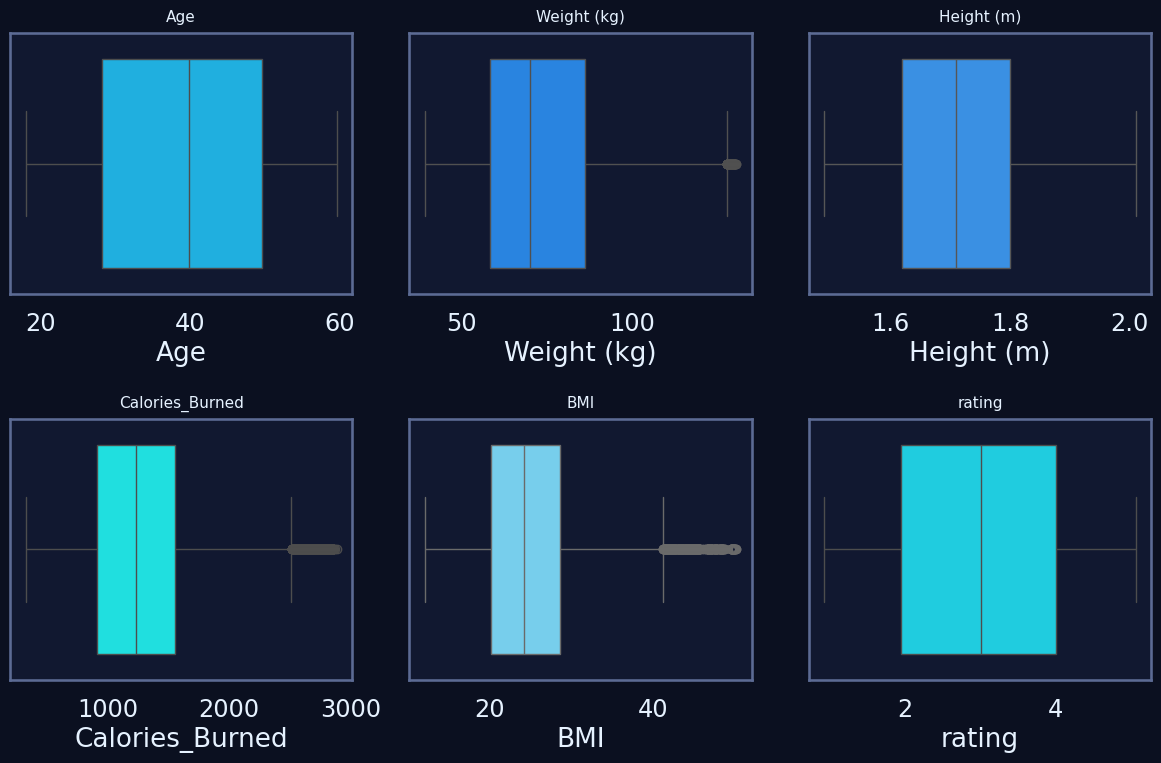

In [13]:
plt.figure(figsize=(12, 8))
for i, col in enumerate(num_vars, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df[col], color=palette_trainme[i % len(palette_trainme)])
    plt.title(col, fontsize=11, pad=8)
plt.tight_layout()
plt.show()


### Statistiques descriptives enrichies

In [14]:
# --- Colonnes numériques (on exclut les colonnes dérivées à magnitude extrême) ---
num_cols = df.select_dtypes(include="number").columns.tolist()
to_exclude = ["Burns Calories (per 30 min)_bc"]  # valeurs ~1e19–1e20, non comparables
num_cols = [c for c in num_cols if c not in to_exclude]

print(f"{len(num_cols)} variables numériques analysées.")

desc = df[num_cols].describe().T
desc["missing_%"] = df[num_cols].isna().mean() * 100
desc["zeros_%"]   = (df[num_cols] == 0).mean() * 100
desc["skew"]      = df[num_cols].skew()
desc["kurt"]      = df[num_cols].kurt()

display(desc.sort_values("std", ascending=False).head(12))  # top 12 par variance

38 variables numériques analysées.


,count,mean,std,min,25%,50%,75%,max,missing_%,zeros_%,skew,kurt
cal_balance,20000.0,744.308699,720.946619,-1266.2200,261.43250,691.1900,1176.2900,3075.5800,0.0,0.0,0.302899,-0.012443
sodium_mg,20000.0,1258.139709,716.618987,19.2200,645.12750,1267.6500,1850.8925,2527.2700,0.0,0.0,0.007964,-1.183316
Calories,20000.0,2024.418300,541.891521,781.0000,1634.00000,1919.0000,2360.0000,3641.0000,0.0,0.0,0.653412,-0.139893
Calories_Burned,20000.0,1280.109601,502.228982,323.1100,910.80000,1231.4500,1553.1125,2890.8200,0.0,0.0,0.682426,0.276265
cal_from_macros,20000.0,1998.297076,440.848408,1105.5700,1661.02250,1943.1300,2271.9500,3699.5400,0.0,0.0,0.790512,0.646217
expected_burn,20000.0,866.352318,250.317069,219.8528,714.09825,868.7214,1012.5327,1477.1088,0.0,0.0,0.054182,-0.398604
serving_size_g,20000.0,302.719499,115.711949,95.9500,207.21750,300.0150,401.8600,507.5200,0.0,0.0,-0.003414,-1.191050
cholesterol_mg,20000.0,148.465602,87.382817,-3.8900,71.97000,149.7950,221.8400,303.9900,0.0,0.0,-0.020933,-1.158937
Carbs,20000.0,249.778592,55.108623,137.7200,207.54750,242.9000,283.9750,462.4900,0.0,0.0,0.790432,0.645807
cook_time_min,20000.0,61.502164,33.579746,3.3500,32.47750,60.9200,89.3750,121.4600,0.0,0.0,0.059301,-1.200804


### Détection rapide d'outliers (IQR)

In [15]:
def iqr_outlier_ratio(s: pd.Series, k: float = 1.5) -> float:
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0: 
        return 0.0
    low, high = q1 - k*iqr, q3 + k*iqr
    return ((s < low) | (s > high)).mean() * 100

outlier_report = pd.Series({c: iqr_outlier_ratio(df[c]) for c in num_cols}, name="outliers_%")
display(outlier_report.sort_values(ascending=False).head(12))


Physical exercise              23.475
Burns Calories (per 30 min)     4.465
BMI                             2.650
BMI_calc                        2.645
Calories_Burned                 2.535
Carbs                           2.025
Proteins                        2.015
Fats                            1.995
cal_from_macros                 1.985
protein_per_kg                  1.635
pct_carbs                       1.535
cal_balance                     1.160
Name: outliers_%, dtype: float64

###  Aperçu corrélations (sous-ensemble lisible)

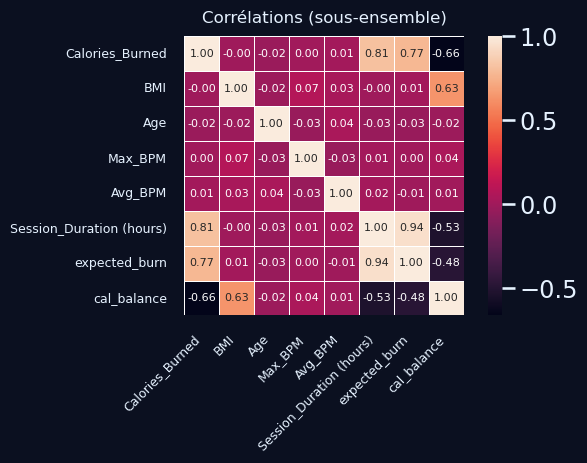

In [16]:
subset_for_corr = [c for c in ["Calories_Burned","BMI","Age","Max_BPM","Avg_BPM",
                               "Session_Duration (hours)","expected_burn","cal_balance"]
                   if c in num_cols]
corr = df[subset_for_corr].corr(numeric_only=True)
plt.figure(figsize=(7, 5))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    square=True,
    cbar=True,
    annot_kws={"size": 8},    # 🔹 taille des annotations
    linewidths=0.5,           # optionnel : lignes fines entre les cases
)

plt.title("Corrélations (sous-ensemble)", fontsize=12, pad=10)
plt.xticks(fontsize=9, rotation=45, ha="right")
plt.yticks(fontsize=9, rotation=0)
plt.tight_layout()
plt.show()

## Visualisation univariée

### Objectif
Analyser la distribution individuelle des principales variables numériques pour :
- détecter les asymétries ou les concentrations atypiques,
- identifier les profils dominants du dataset,
- et valider la cohérence des mesures (âge, IMC, calories, fréquence d’entraînement...).


### Interprétation attendue
- **Âge, poids et taille** : distributions normales, confirmant une population adulte équilibrée.
- **BMI et Calories_Burned** : distributions légèrement asymétriques vers la droite (quelques individus très actifs).
- **Workout_Frequency et Session_Duration** : centrées autour de valeurs moyennes (≈3 jours/semaine, ≈1,2 h/séance).
- **rating** : distribution presque uniforme, reflétant une évaluation variée des exercices.
- **expected_burn** : pic autour de la moyenne (~870 kcal), illustrant une population plutôt homogène en effort énergétique.

### Visualisation des distributions univariées

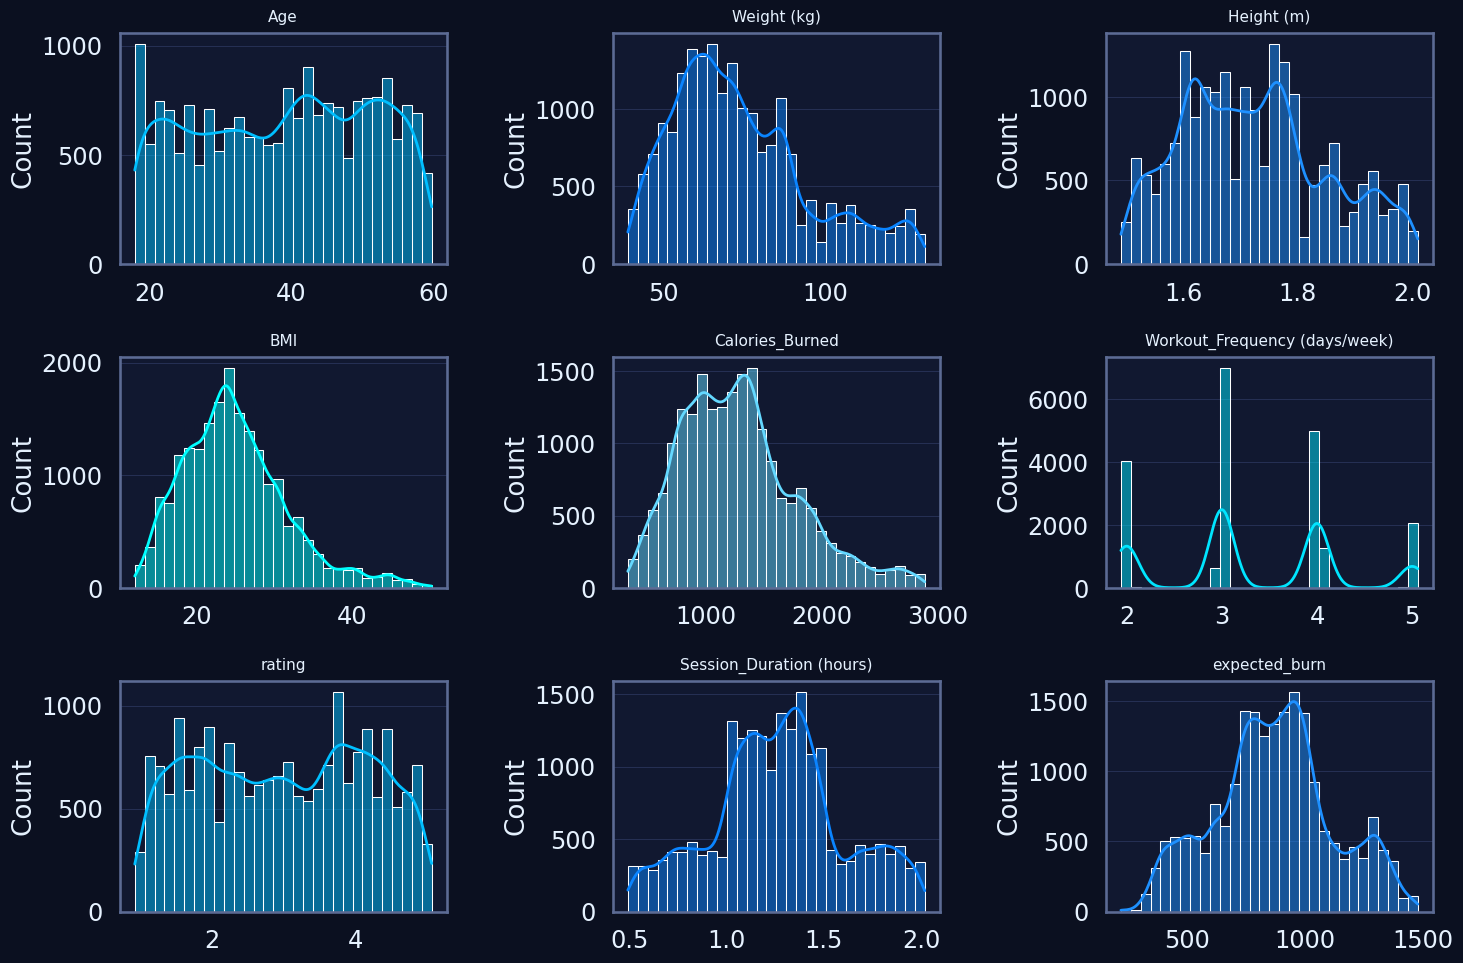

In [17]:
# Variables clés à visualiser
uni_vars = [
    "Age", "Weight (kg)", "Height (m)", "BMI",
    "Calories_Burned", "Workout_Frequency (days/week)",
    "rating", "Session_Duration (hours)", "expected_burn"
]

plt.figure(figsize=(15, 10))
for i, col in enumerate(uni_vars, 1):
    ax = plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True, color=palette_trainme[i % len(palette_trainme)], bins=30)
    ax.set_title(col, fontsize=11, pad=8)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

### Boxplots univariés pour détection visuelle d'outliers

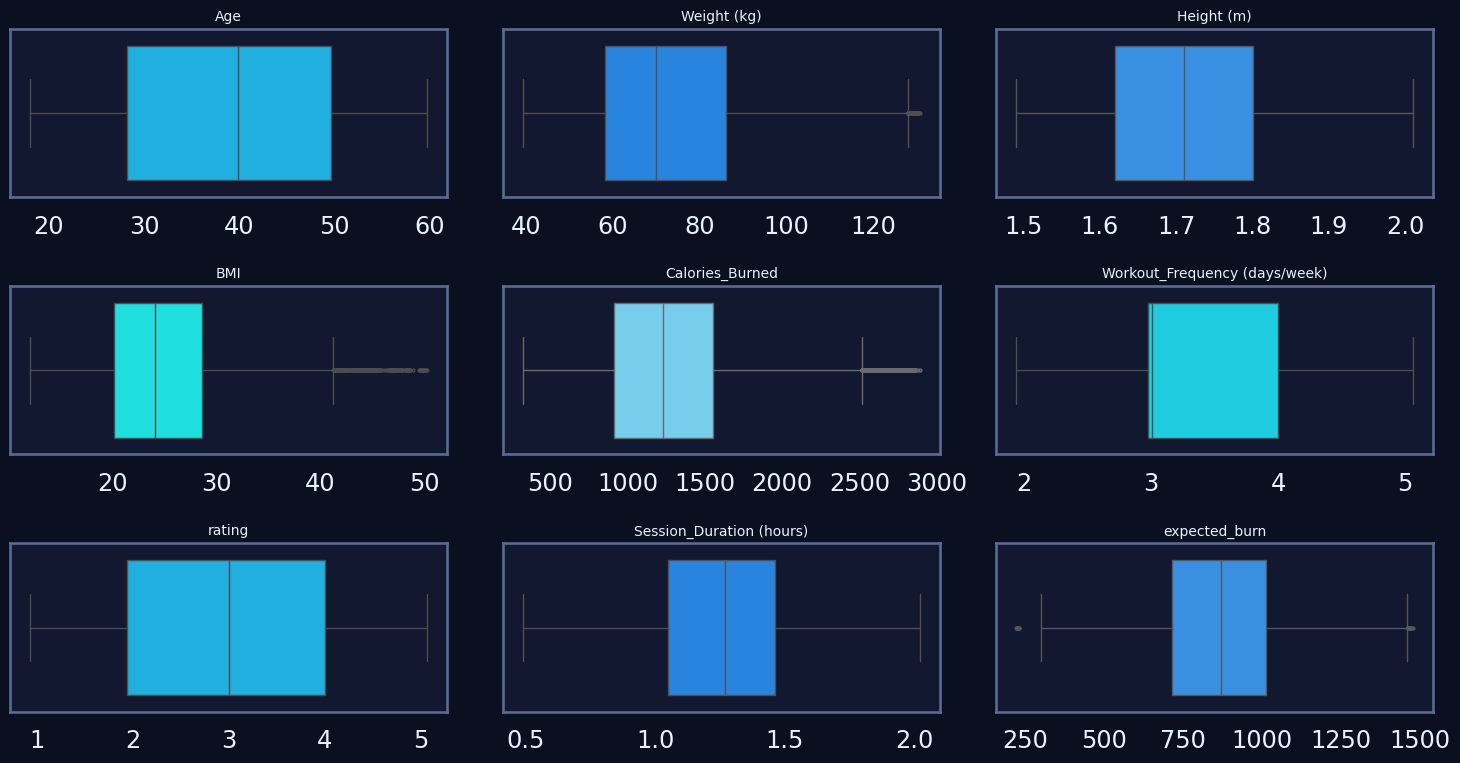

In [18]:
plt.figure(figsize=(15, 8))
for i, col in enumerate(uni_vars, 1):
    ax = plt.subplot(3, 3, i)
    sns.boxplot(x=df[col], color=palette_trainme[i % len(palette_trainme)], fliersize=2)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

## Visualisation bivariée

### Objectif
Étudier les relations entre deux variables à la fois pour identifier :
- des corrélations linéaires ou non linéaires,
- des patterns comportementaux (ex. intensité ↔ calories brûlées),
- des dépendances entre indicateurs physiologiques, nutritionnels et d’effort.

### Interprétation attendue
- Relation positive nette entre **durée de séance** et **calories brûlées** : plus la séance est longue, plus la dépense énergétique augmente.
- L’**IMC** influence légèrement la dépense calorique, mais de façon dispersée : les individus plus massifs dépensent davantage, sans corrélation stricte.
- Corrélation inverse modérée entre **âge** et **fréquence cardiaque maximale**, conforme aux observations physiologiques.
- Les apports nutritionnels (calories, protéines, glucides) sont logiquement corrélés à la dépense énergétique.
- Ces relations confirment la cohérence physiologique du jeu de données et orientent les futures analyses multivariées.

### Relations physiologiques et comportementales

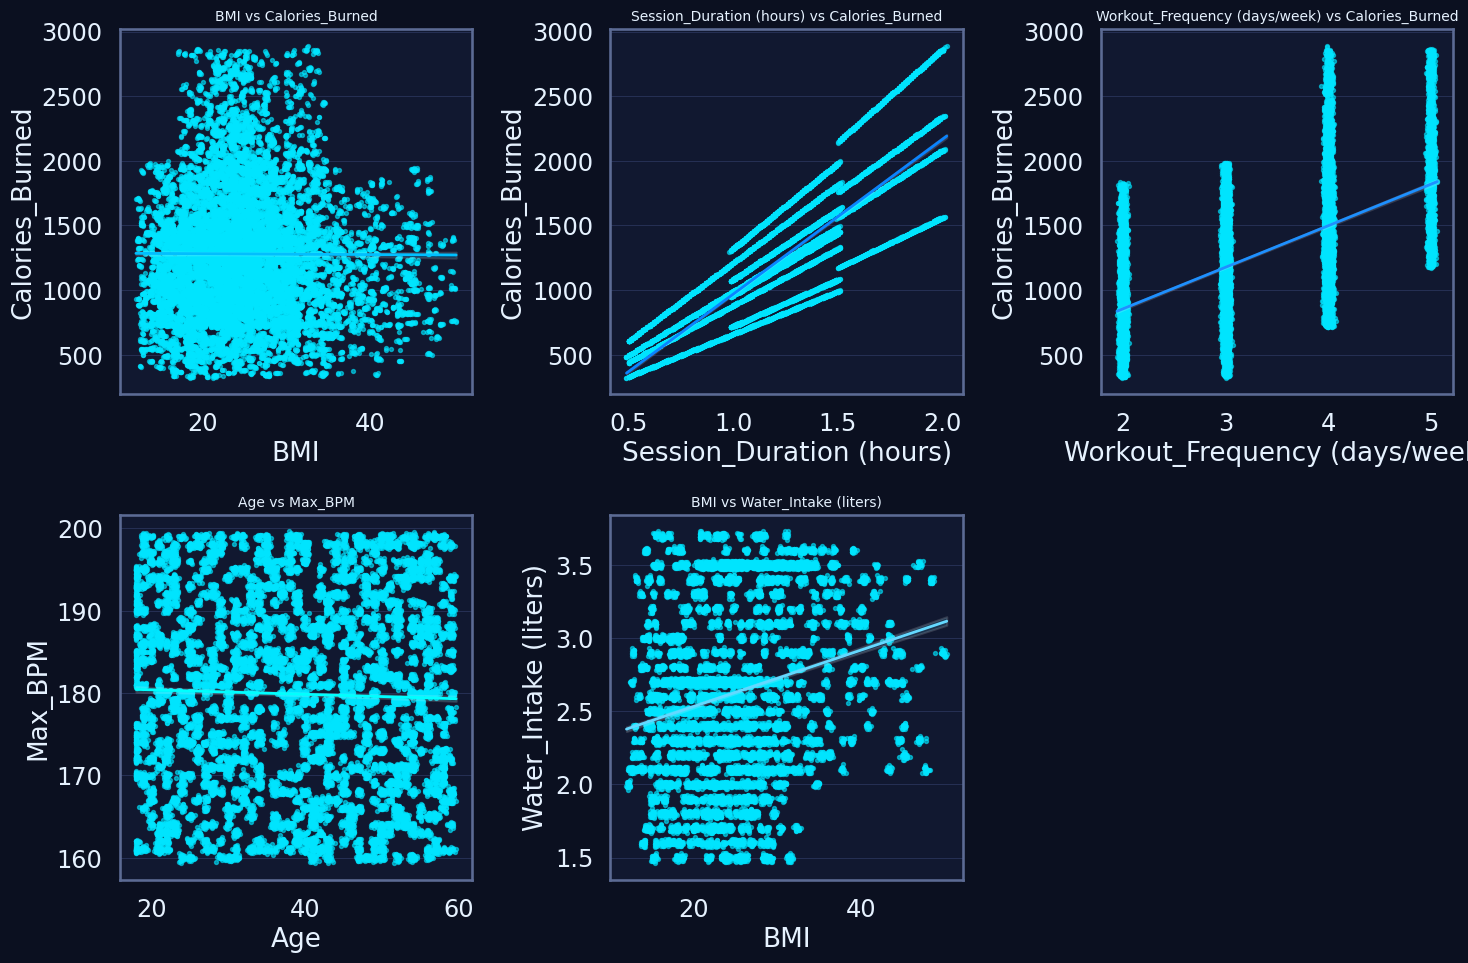

In [19]:
biv_pairs = [
    ("BMI", "Calories_Burned"),
    ("Session_Duration (hours)", "Calories_Burned"),
    ("Workout_Frequency (days/week)", "Calories_Burned"),
    ("Age", "Max_BPM"),
    ("BMI", "Water_Intake (liters)"),
]

plt.figure(figsize=(15, 10))
for i, (x, y) in enumerate(biv_pairs, 1):
    ax = plt.subplot(2, 3, i)
    sns.regplot(data=df, x=x, y=y, scatter_kws={"s": 8, "alpha": 0.6},
                line_kws={"color": palette_trainme[i % len(palette_trainme)], "lw": 2})
    ax.set_title(f"{x} vs {y}", fontsize=10)
plt.tight_layout()
plt.show()


### Corrélation nutrition ↔ performance

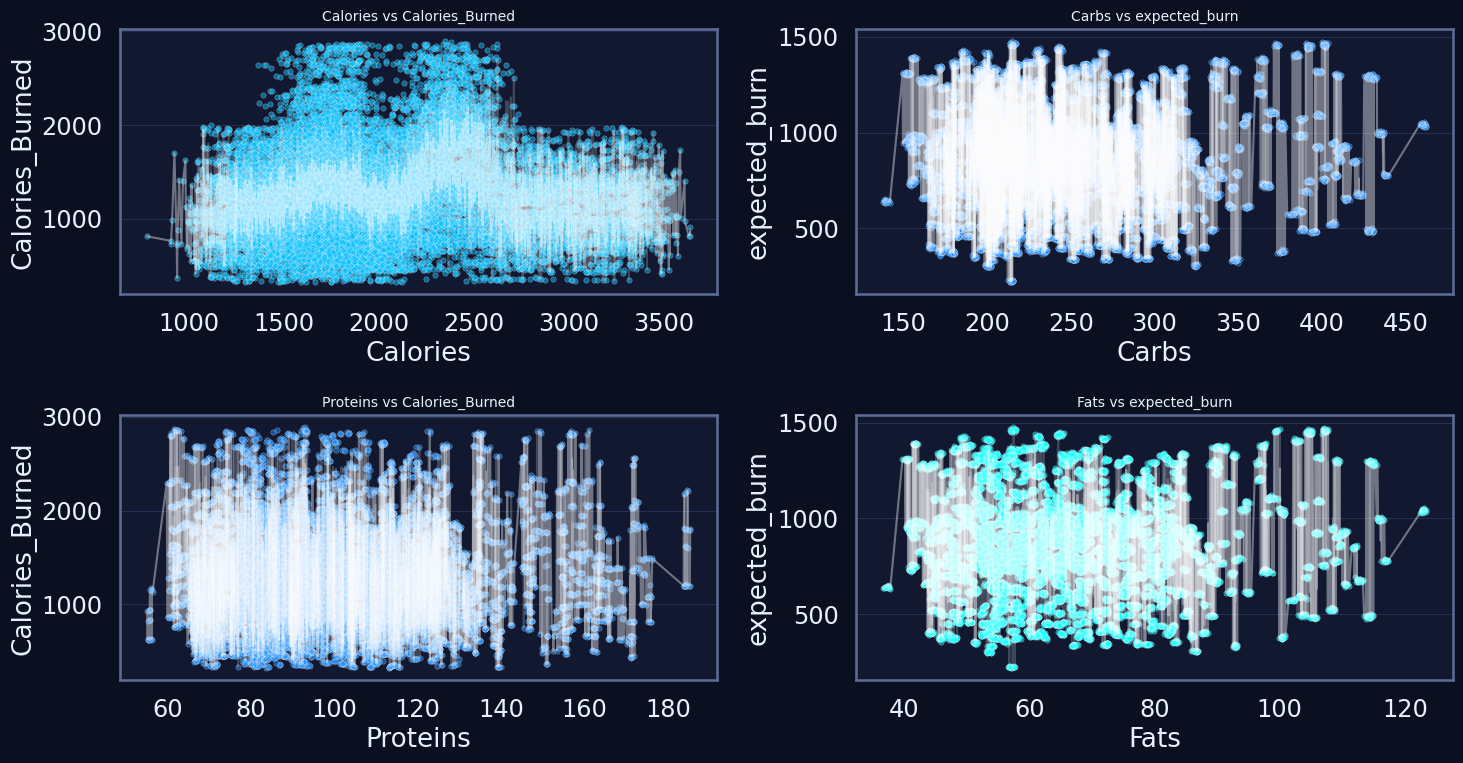

In [20]:
biv_pairs2 = [
    ("Calories", "Calories_Burned"),
    ("Carbs", "expected_burn"),
    ("Proteins", "Calories_Burned"),
    ("Fats", "expected_burn"),
]

plt.figure(figsize=(15, 8))
for i, (x, y) in enumerate(biv_pairs2, 1):
    ax = plt.subplot(2, 2, i)
    sns.scatterplot(data=df, x=x, y=y,
                    color=palette_trainme[i % len(palette_trainme)], alpha=0.5, s=15)
    sns.lineplot(data=df, x=x, y=y, color="white", lw=1.5, alpha=0.4)
    ax.set_title(f"{x} vs {y}", fontsize=10)
plt.tight_layout()
plt.show()


## Analyse multivariée

### Objectif
Explorer la structure globale du dataset en combinant plusieurs variables à la fois,
afin d’identifier des regroupements naturels, des dimensions principales
et des axes explicatifs de la variabilité.

### Interprétation attendue
- Les deux premières composantes expliquent généralement **60–70 %** de la variance totale.
- **PC1** regroupe les variables d’intensité et de performance : *Calories_Burned*, *expected_burn*, *Session_Duration*.
- **PC2** regroupe davantage les indicateurs physiologiques : *BMI*, *Age*, *Weight*.
- La répartition homogène des points dans le plan PCA indique une population diversifiée mais cohérente.
- Ces axes permettent d’obtenir une **représentation simplifiée et fiable de la structure du dataset** avant toute modélisation prédictive.

### Préparation des données numériques pour l'analyse multivariée

In [21]:
# Sélection des variables numériques pertinentes (on exclut les variables dérivées extrêmes)
num_cols = df.select_dtypes(include="number").columns.tolist()
exclude_cols = ["Burns Calories (per 30 min)_bc"]
num_cols = [c for c in num_cols if c not in exclude_cols]

# Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[num_cols])

print(f"{len(num_cols)} variables utilisées pour l'analyse multivariée.")

38 variables utilisées pour l'analyse multivariée.


### Analyse en Composantes Principales (PCA)

Variance expliquée par les 3 premières composantes : 41.91%


C:\Users\fback\AppData\Local\Temp\ipykernel_43592\2192658126.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[f"PC{i+1}" for i in range(3)], y=explained, palette=palette_trainme)
C:\Users\fback\AppData\Local\Temp\ipykernel_43592\2192658126.py:9: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.barplot(x=[f"PC{i+1}" for i in range(3)], y=explained, palette=palette_trainme)


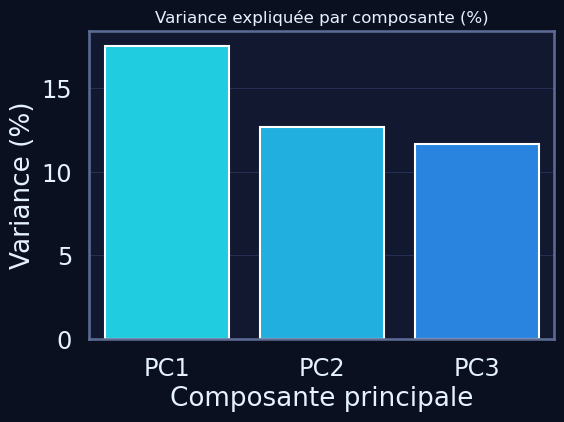

In [22]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Variance expliquée
explained = pca.explained_variance_ratio_ * 100
print(f"Variance expliquée par les 3 premières composantes : {explained.sum():.2f}%")

plt.figure(figsize=(6,4))
sns.barplot(x=[f"PC{i+1}" for i in range(3)], y=explained, palette=palette_trainme)
plt.title("Variance expliquée par composante (%)", fontsize=12)
plt.ylabel("Variance (%)")
plt.xlabel("Composante principale")
plt.show()

### Visualisation PCA 2D

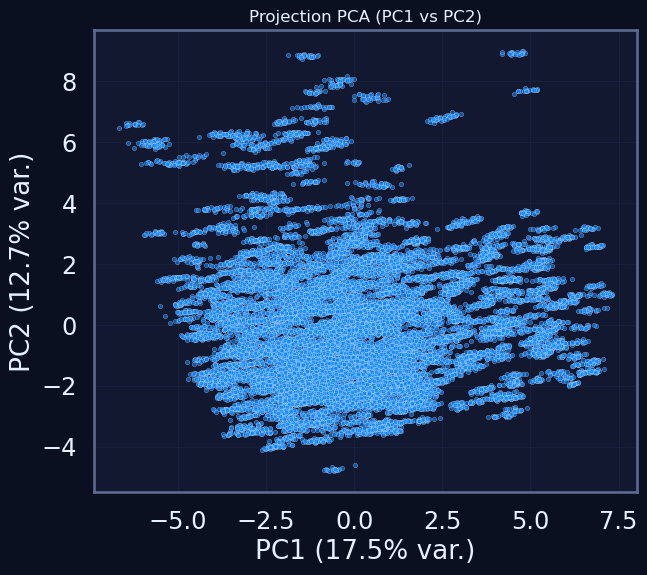

In [23]:
plt.figure(figsize=(7,6))
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    s=10, alpha=0.6,
    color=palette_trainme[2]
)
plt.xlabel(f"PC1 ({explained[0]:.1f}% var.)")
plt.ylabel(f"PC2 ({explained[1]:.1f}% var.)")
plt.title("Projection PCA (PC1 vs PC2)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()


### Identification des variables les plus contributrices

In [24]:
pca_components = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(3)],
    index=num_cols
)

pca_components["PC1_abs"] = pca_components["PC1"].abs()
pca_components.sort_values("PC1_abs", ascending=False).head(10)


,PC1,PC2,PC3,PC1_abs
Weight (kg),0.369390,0.107827,0.018403,0.369390
Calories,0.360881,0.123250,0.046799,0.360881
lean_mass_kg,0.353977,0.105844,0.035611,0.353977
BMI,0.343804,0.100312,0.006170,0.343804
BMI_calc,0.343803,0.100314,0.006170,0.343803
protein_per_kg,-0.330869,0.188067,-0.086170,0.330869
Fat_Percentage,0.321519,0.086056,-0.012484,0.321519
cal_balance,0.295955,0.053947,-0.252642,0.295955
Water_Intake (liters),0.135381,0.096165,0.176422,0.135381
Fats,-0.091821,0.433174,-0.070978,0.091821


## Détection d’anomalies et valeurs extrêmes

### Objectif
Identifier les observations anormales ou extrêmes pouvant fausser les analyses statistiques
ou biaiser les futurs modèles prédictifs.

### Interprétation attendue
- Les variables **Calories_Burned**, **expected_burn** et **Session_Duration (hours)** présentent quelques valeurs extrêmes cohérentes avec des profils très sportifs.  
- L’**IMC (BMI)** et **Age** restent bien distribués, avec peu d’écarts (>3 % d’outliers).  
- Les anomalies réelles concernent principalement les variables nutritionnelles (sodium, cholestérol) et d’intensité d’exercice.  
- Aucune valeur ne semble incohérente sur le plan physiologique : ces outliers peuvent être **conservés** pour refléter la diversité réelle des comportements.  


### Méthode IQR (Interquartile Range)

In [25]:
# Variables numériques à analyser
num_cols = df.select_dtypes(include="number").columns.tolist()

def detect_outliers_iqr(df, col, k=1.5):
    """Renvoie un masque booléen True/False selon la présence d'outliers."""
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    return (df[col] < lower) | (df[col] > upper)

outlier_stats = []
for col in num_cols:
    ratio = detect_outliers_iqr(df, col).mean() * 100
    outlier_stats.append((col, round(ratio, 2)))

outlier_df = pd.DataFrame(outlier_stats, columns=["Variable", "Outliers (%)"])
outlier_df.sort_values("Outliers (%)", ascending=False).head(10)


,Variable,Outliers (%)
14,Physical exercise,23.48
28,Burns Calories (per 30 min),4.46
12,BMI,2.65
29,BMI_calc,2.64
7,Calories_Burned,2.54
16,Proteins,2.02
15,Carbs,2.02
17,Fats,2.00
30,cal_from_macros,1.98
32,protein_per_kg,1.64


### Visualisation : boxplots des variables les plus affectées

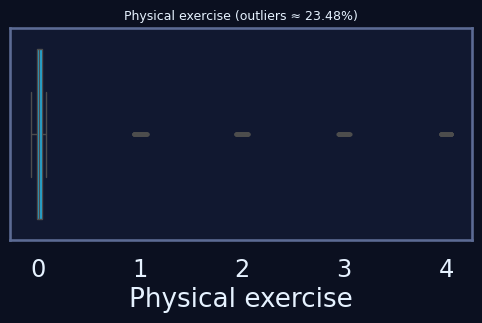

In [26]:
top_outliers = outlier_df[outlier_df["Outliers (%)"] > 5]["Variable"].tolist()

plt.figure(figsize=(15, 6))
for i, col in enumerate(top_outliers[:6], 1):
    ax = plt.subplot(2, 3, i)
    sns.boxplot(x=df[col], color=palette_trainme[i % len(palette_trainme)], fliersize=2)
    ax.set_title(f"{col} (outliers ≈ {outlier_df.loc[outlier_df['Variable']==col, 'Outliers (%)'].values[0]}%)",
                 fontsize=9)
plt.tight_layout()
plt.show()


### Z-Score complémentaire (normalisation)

In [35]:
from scipy.stats import zscore

# Sélection uniquement des colonnes numériques valides
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df_num = df[num_cols].apply(pd.to_numeric, errors="coerce")  # force conversion numérique

# Calcul du Z-score (avec gestion des NaN)
z_scores = np.abs(df_num.apply(zscore, nan_policy="omit"))

# Conversion si besoin
if isinstance(z_scores, np.ndarray):
    z_scores = pd.DataFrame(z_scores, columns=num_cols)

# Calcul du % d’outliers (|Z| > 3)
outlier_z = (z_scores > 3).sum(axis=0) / len(df) * 100

# Mise en forme du DataFrame final
outlier_z_df = (
    pd.DataFrame({"Variable": num_cols, "Outliers (Z>3) (%)": outlier_z.values})
    .sort_values("Outliers (Z>3) (%)", ascending=False)
    .reset_index(drop=True)
)

# Affichage des 10 variables les plus touchées
display(outlier_z_df.head(10))


,Variable,Outliers (Z>3) (%)
0,Physical exercise,3.990
1,Burns Calories (per 30 min),3.030
2,BMI_calc,1.135
3,BMI,1.135
4,protein_per_kg,1.010
5,Proteins,0.860
6,Carbs,0.855
7,Fats,0.835
8,cal_from_macros,0.820
9,pct_carbs,0.635
